<a href="https://colab.research.google.com/github/LuizaRamos/TOL506M_Final_Project/blob/main/notebooks/00_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÖL506M - Introduction to Deep Neural Network
## Final Project: Wildlife Image Classification
### Data Exploration
**name:** Luiza V Sampaio Ramos, **email:** lvs2@gmail.com

In [9]:
# --- Colab setup for running notebooks with local package-style imports ---
#                 The code below, was generated by ChatGPT

# 1) Configure your repo details
REPO_URL = "https://github.com/LuizaRamos/TOL506M_Final_Project.git"
REPO_DIR = "/content/TOL506M_Final_Project"

# 2) Clone or update the repo
import os, sys, subprocess, pathlib

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    # pull latest; safe if you want current main
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)

# 3) Make the repo root the working directory
os.chdir(REPO_DIR)

# 4) Put the repo on PYTHONPATH so `from utils import ...` etc. works
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.environ["PYTHONPATH"] = REPO_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

# 5) (Optional) install dependencies if you have a requirements.txt or pyproject
if os.path.exists("requirements.txt"):
    # quiet install
    subprocess.run(["pip", "install", "-q", "-r", "requirements.txt"], check=True)

In [1]:
# Imports
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import torch
from torchvision import datasets, transforms

# Setup
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

print(f'PyTorch version: {torch.__version__}\n')
print(f'CUDA available: {torch.cuda.is_available()}\n')

PyTorch version: 2.8.0

CUDA available: False



In [11]:
from google.colab import drive
drive.mount("/content/drive")

PERSIST_DIR = Path("/content/drive/MyDrive/Háskoli_Íslands/TÖL506M/TOL506M_Final_Project/")  # change as you like
PERSIST_DIR.mkdir(parents=True, exist_ok=True)

# Point the repo's results directory at a persistent location
(REPO_DIR_PATH := Path(REPO_DIR)).mkdir(parents=True, exist_ok=True)
results_link = REPO_DIR_PATH / "results"
if results_link.exists() or results_link.is_symlink():
    results_link.unlink()
results_link.symlink_to(PERSIST_DIR, target_is_directory=True)

print("Results now persist at:", PERSIST_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results now persist at: /content/drive/MyDrive/Háskoli_Íslands/TÖL506M/TOL506M_Final_Project


In [16]:
REPO_DIR = Path("/content/drive/MyDrive/Háskoli_Íslands/TÖL506M/TOL506M_Final_Project")
sys.path.insert(0, str(REPO_DIR))

# move into repo root so relative paths work
%cd $REPO_DIR

/content/drive/MyDrive/Háskoli_Íslands/TÖL506M/TOL506M_Final_Project


In [2]:
from data.dataset import get_data

DATA_PATH = get_data()

/Users/luizaramos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/luizaramos/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded: /Users/luizaramos/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2



In [3]:
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=str(DATA_PATH), transform=basic_transform)

print(f'Total images: {len(dataset)}\n')
print(f'Classes: {dataset.classes}\n')

Total images: 26179

Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']



In [4]:
# Translating from Italian to English, obtained from https://www.kaggle.com/datasets/alessiocorrado99/animals10/data
it2en = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel",
}

# dataset.class_to_idx maps italian_name -> index
italian_to_idx = dataset.class_to_idx
idx_to_italian = {idx: name for name, idx in italian_to_idx.items()}
idx_to_english = {idx: it2en.get(name, name) for idx, name in idx_to_italian.items()}

# Check English class names in index order
print("Index -> Italian -> English")
for idx in sorted(idx_to_italian):
    print(f"{idx:2d} -> {idx_to_italian[idx]:12s} -> {idx_to_english[idx]:12s}")


Index -> Italian -> English
 0 -> cane         -> dog         
 1 -> cavallo      -> horse       
 2 -> elefante     -> elephant    
 3 -> farfalla     -> butterfly   
 4 -> gallina      -> chicken     
 5 -> gatto        -> cat         
 6 -> mucca        -> cow         
 7 -> pecora       -> sheep       
 8 -> ragno        -> spider      
 9 -> scoiattolo   -> squirrel    


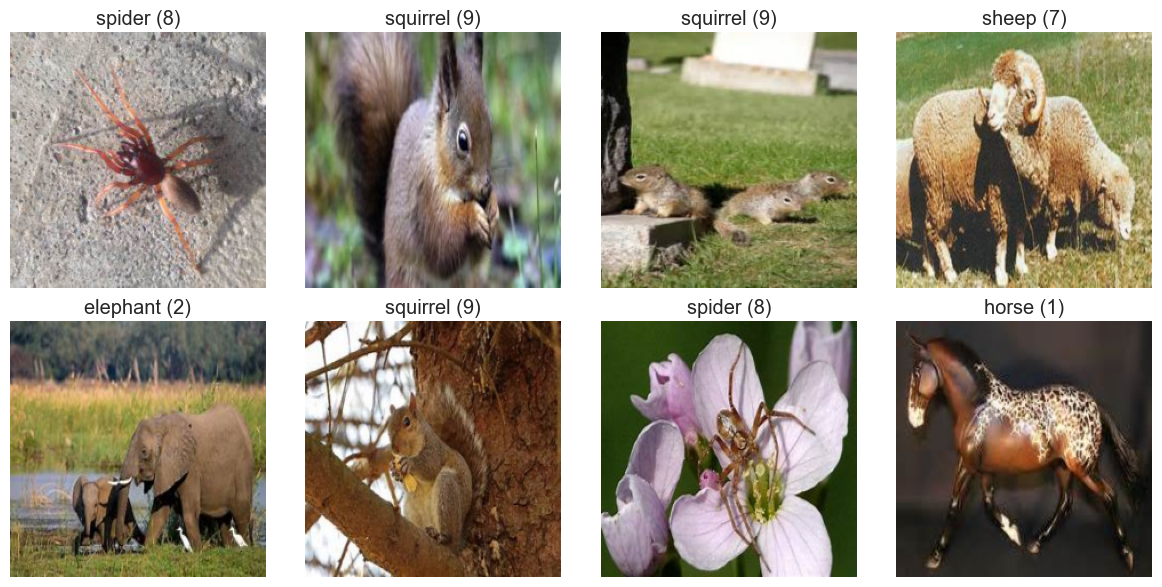

In [5]:
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

loader = DataLoader(dataset, batch_size=8, shuffle=True)

# get one batch
images, labels = next(iter(loader))

# simple denormalize for visualization (if you normalized)
def denormalize(img):
    # If you used ImageNet normalization, implement inverse here.
    return img.permute(1, 2, 0).numpy().clip(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()
for i, ax in enumerate(axes):
    img = denormalize(images[i])
    true_idx = int(labels[i].item())
    english_label = idx_to_english[true_idx]
    ax.imshow(img)
    ax.set_title(f"{english_label} ({true_idx})")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
num_classes = len(dataset.classes)
class_names_english = [idx_to_english[i] for i in range(num_classes)]
print("English class names:", class_names_english)

English class names: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


In [7]:
# Class Distribution Analysis
labels = [label for _, label in dataset.imgs]
class_counts = Counter(labels)

percentages = {label: (count / len(labels)) * 100 for label, count in class_counts.items()}

# Sort by percentage in descending order
sorted_classes = sorted(percentages.items(), key=lambda x: x[1], reverse=True)

for label, percentages in sorted_classes:
    print(f"{percentages:.2f}% are {idx_to_english[label]} - {class_counts[label]} images")

18.58% are dog - 4863 images
18.42% are spider - 4821 images
11.83% are chicken - 3098 images
10.02% are horse - 2623 images
8.07% are butterfly - 2112 images
7.13% are cow - 1866 images
7.11% are squirrel - 1862 images
6.95% are sheep - 1820 images
6.37% are cat - 1668 images
5.52% are elephant - 1446 images


In [8]:
imgs_per_class = np.zeros(num_classes)
for i in range(num_classes):
    imgs_per_class[i] = class_counts[i]

# Statistics:
print(f' Mean images per class: {np.mean(imgs_per_class):.2f}')
print(f' Std images per class: {np.std(imgs_per_class):.2f}')
print(f' Min images per class: {np.min(imgs_per_class):.0f}')
print(f' Max images per class: {np.max(imgs_per_class):.0f}')

 Mean images per class: 2617.90
 Std images per class: 1201.23
 Min images per class: 1446
 Max images per class: 4863


In [9]:
# Analysing Image Dimensions
widths = []
heights = []
aspect_ratios = []

sample_indices = np.random.choice(len(dataset), size=1000, replace=False)

for idx in sample_indices:
    img_path, _ = dataset.imgs[idx]
    with Image.open(img_path) as img:
      w, h = img.size
      widths.append(w)
      heights.append(h)
      aspect_ratios.append(w / h)

print(f'Width: Mean {np.mean(widths):.2f}, Std {np.std(widths):.2f}, Min {np.min(widths):.0f}, Max {np.max(widths):.0f}')
print(f'Height: Mean {np.mean(heights):.2f}, Std {np.std(heights):.2f}, Min {np.min(widths):.0f}, Max {np.max(widths):.0f}')
print(f'Aspect Ratio: Mean {np.mean(aspect_ratios):.2f}, Std {np.std(aspect_ratios):.2f}, Min {np.min(aspect_ratios):.2f}, Max {np.max(aspect_ratios):.2f}')

Width: Mean 323.12, Std 226.97, Min 60, Max 4928
Height: Mean 256.51, Std 153.20, Min 60, Max 4928
Aspect Ratio: Mean 1.29, Std 0.30, Min 0.41, Max 2.34


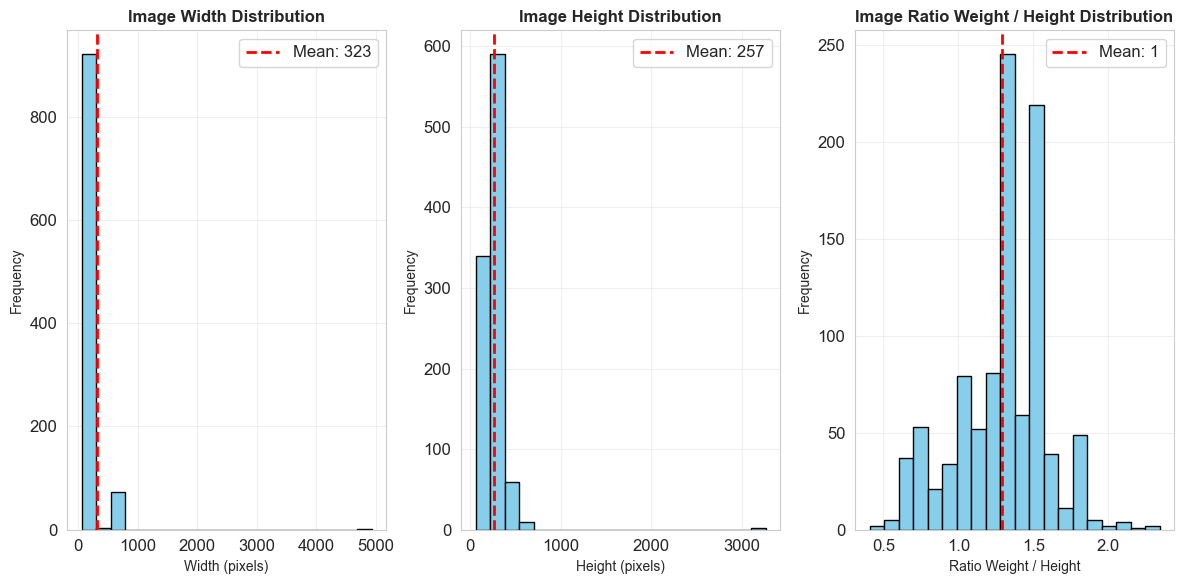

In [10]:
# Visualization of the Image Size Distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Plot for Width
axes[0].hist(widths, bins=20, color='skyblue', edgecolor='black')
axes[0].axvline(np.mean(widths), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(widths):.0f}')
axes[0].set_xlabel('Width (pixels)', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].set_title('Image Width Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot for Height
axes[1].hist(heights, bins=20, color='skyblue', edgecolor='black')
axes[1].axvline(np.mean(heights), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(heights):.0f}')
axes[1].set_xlabel('Height (pixels)', fontsize=10)
axes[1].set_ylabel('Frequency', fontsize=10)
axes[1].set_title('Image Height Distribution', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot for the Ratio (Weight / Height)
axes[2].hist(aspect_ratios, bins=20, color='skyblue', edgecolor='black')
axes[2].axvline(np.mean(aspect_ratios), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(aspect_ratios):.0f}')
axes[2].set_xlabel('Ratio Weight / Height', fontsize=10)
axes[2].set_ylabel('Frequency', fontsize=10)
axes[2].set_title('Image Ratio Weight / Height Distribution', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Data Split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

print(f'Train size: {train_size}')
print(f'Validation size: {val_size}')
print(f'Test size: {test_size}')

Train size: 18325
Validation size: 3926
Test size: 3928


In [17]:
from data.dataset import get_data_loaders, get_class_names
from config import Config

config = Config()

# Set random seed for reproducibility
torch.manual_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.RANDOM_SEED)

train_loader, val_loader, test_loader, class_names = get_data_loaders(
    DATA_PATH,
    batch_size=config.BATCH_SIZE,
    num_workers=config.NUM_WORKERS,
    train_split=config.TRAIN_SPLIT,
    val_split=config.VAL_SPLIT,
    test_split=config.TEST_SPLIT,
    use_augmentation=config.USE_AUGMENTATION,
    random_seed=config.RANDOM_SEED,
    data_fraction=1.0
)

In [24]:
# get one batch
train_img, train_labels = next(iter(train_loader))
val_img, val_labels = next(iter(val_loader))
test_img, test_labels = next(iter(test_loader))

def evaluate_data_distribution(labels):

    class_counts = Counter(labels)

    percentages = {label: (count / len(labels)) * 100 for label, count in class_counts.items()}

    # Sort by percentage in descending order
    sorted_classes = sorted(percentages.items(), key=lambda x: x[1], reverse=True)

    for label, percentage in sorted_classes:
        print(f"{percentage:.2f}% are {idx_to_english[label]} - {class_counts[label]} images")

    imgs_per_class = np.zeros(num_classes)
    for i in range(num_classes):
        imgs_per_class[i] = class_counts.get(i, 0)  # Use .get() to handle missing classes

    # Statistics:
    print(f' Mean images per class: {np.mean(imgs_per_class):.2f}')
    print(f' Std images per class: {np.std(imgs_per_class):.2f}')
    print(f' Min images per class: {np.min(imgs_per_class):.0f}')
    print(f' Max images per class: {np.max(imgs_per_class):.0f}')

/Users/luizaramos/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/luizaramos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/luizaramos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/luizaramos/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2

In [27]:
len(train_labels)

32

In [ ]:
evaluate_data_distribution(val_labels)

In [ ]:
evaluate_data_distribution(test_labels)